In [1]:
from langgraph.graph import START,StateGraph,END
from pydantic import BaseModel,Field
from typing import TypedDict,Literal,Annotated
from langchain_core.messages import HumanMessage,SystemMessage

In [2]:
from langchain_ollama import  ChatOllama


In [29]:
genrater_llm=ChatOllama(model='qwen2.5:3b')
evaluator_llm=ChatOllama(model='qwen2.5:3b')
optimizer_llm=ChatOllama(model='qwen2.5:3b')

In [30]:
class tweeterevaluation(BaseModel):
    evaluation:Literal['approved','needs_improvment']=Field(...,description='Final evaluation result')
    
    feedback:str=Field(...,description='feedback for the tweet')

In [31]:
stuctured_evaluator_llm=evaluator_llm.with_structured_output(tweeterevaluation)

In [32]:
# define state
import operator
class tweerstate(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal["approved", "needs_improvement"]
    feedback:str
    iteration:int
    max_iteration:int
    
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]
    

In [33]:
graph=StateGraph(tweerstate)
def genrate_tweet(state:tweerstate):
    # give prompt to llm
    message=[
    SystemMessage(content="You are a funny and clever Twitter/X influencer."),
    HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ] 
    # sent this message to gerater llm
    response=genrater_llm.invoke(message)

    return {'tweet':response,'tweet_history':[response]}





In [34]:
def evaluate_tweet(state:tweerstate):
    # give promt to evaluator llm
    message=[
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
        
]
    respone=stuctured_evaluator_llm.invoke(message)
    return {'evaluation':respone,"feedback": respone.feedback,'feedback_history':[respone.feedback]}


In [35]:
# now build the optimize node
def optimize_tweet(state:tweerstate):
    # prompt
     messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

     response=optimizer_llm.invoke(messages)
     iteration=state['iteration']+1

     return {'tweet':response,'iteration':iteration,'tweet_history':[response]}

In [36]:
def route_evaluation(state:tweerstate):
    if state['evaluation']=='approved'or state['iteration']>=state['max_iteration']:
        
        return 'approved'
    else:
        return 'needs_improvement'

In [37]:
graph=StateGraph(tweerstate)
graph.add_node('genrate',genrate_tweet)

graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimize',optimize_tweet)
graph.add_edge(START,'genrate')
graph.add_edge('genrate','evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'approved':END,'needs_improvement':'optimize'})
graph.add_edge('optimize','evaluate')
wokflow=graph.compile()

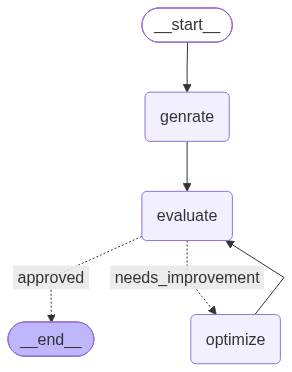

In [38]:
wokflow

In [40]:
user={
    'topic':'school life',
    'iteration':1,
    'max_iteration':5
}
reslut=wokflow.invoke(user)
reslut

{'topic': 'school life',
 'tweet': AIMessage(content='"Math class? Snap to it! 🙄 Swipe right on our school memes #schoolmemes"', additional_kwargs={}, response_metadata={'model': 'qwen2.5:3b', 'created_at': '2026-08-01T15:50:38.0928059Z', 'done': True, 'done_reason': 'stop', 'total_duration': 16211046200, 'load_duration': 268957900, 'prompt_eval_count': 437, 'prompt_eval_duration': 13535104000, 'eval_count': 23, 'eval_duration': 2352930000, 'logprobs': None, 'model_name': 'qwen2.5:3b', 'model_provider': 'ollama'}, id='lc_run--019fbe04-edb7-7bb1-8919-c0f98f65b92e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 437, 'output_tokens': 23, 'total_tokens': 460}),
 'evaluation': tweeterevaluation(evaluation='needs_improvment', feedback="The tweet appears to be a response to some sort of model call, likely related to generating school-related memes. It is well-formatted under 280 characters but lacks originality as it seems to directly quote the generated content with

In [39]:
user = {"topic": "school life", "iteration": 1, "max_iteration": 5}

# Stream events to see live progress
for event in wokflow.stream(user):
  print(event)
  print("-" * 40)

{'genrate': {'tweet': AIMessage(content='"Today in class: I asked why we\'re learning about the Spanish flu pandemic and someone smartly replied \'because it can happen again\'. Talk about future proofing! 🧠😷"', additional_kwargs={}, response_metadata={'model': 'qwen2.5:3b', 'created_at': '2026-08-01T15:43:00.4990021Z', 'done': True, 'done_reason': 'stop', 'total_duration': 16878248000, 'load_duration': 9036400100, 'prompt_eval_count': 96, 'prompt_eval_duration': 2914874000, 'eval_count': 40, 'eval_duration': 4679235000, 'logprobs': None, 'model_name': 'qwen2.5:3b', 'model_provider': 'ollama'}, id='lc_run--019fbdfd-efa1-7e72-84d9-6951c35f045a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 96, 'output_tokens': 40, 'total_tokens': 136}), 'tweet_history': [AIMessage(content='"Today in class: I asked why we\'re learning about the Spanish flu pandemic and someone smartly replied \'because it can happen again\'. Talk about future proofing! 🧠😷"', additional_kwargs={